In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')

In [2]:
x,y=mnist['data'],mnist['target']

In [3]:
x.shape

(70000, 784)

In [4]:
type(y)

pandas.core.series.Series

In [5]:
%matplotlib inline

In [6]:
import matplotlib
import matplotlib.pyplot as plt

In [7]:
import numpy as np
digit = np.array(x.iloc[279])
digit_img = digit.reshape(28,28)

(-0.5, 27.5, 27.5, -0.5)

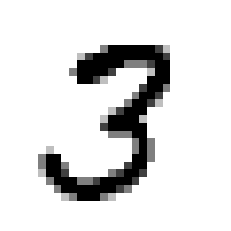

In [8]:
plt.imshow(digit_img,cmap=matplotlib.cm.binary , interpolation="nearest")
plt.axis("off")

In [9]:
y.iloc[278]

'5'

In [10]:
x_train, x_test = x[:60000],x[60000:]
y_train, y_test=y[:60000],y[60000:]

In [11]:
import numpy as np
shuffled = np.random.permutation(60000)
x_train = x_train.iloc[shuffled]
y_train = y_train.iloc[shuffled]

In [12]:
y_train= y_train.astype("int8")
y_test= y_test.astype("int8")
y_train_5 = (y_train==5)
y_test_5 = (y_test==5)

In [13]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(x_train)
x_scaled = scaler.transform(x_train)


In [14]:
digit5 = np.array(x.iloc[2401])
y.iloc[2401]

'5'

In [15]:
digit1 = np.array(x.iloc[2407])
y.iloc[2405]

'5'

In [16]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(tol=0.1,solver="lbfgs",max_iter=500)

In [17]:
clf.fit(x_scaled,y_train_5)

LogisticRegression(max_iter=500, tol=0.1)

In [18]:
clf.predict([digit5])

array([ True])

In [19]:
from sklearn.model_selection import cross_val_score
a= cross_val_score(clf,x_scaled,y_train_5,cv=3,scoring="accuracy")

In [20]:
a.mean()

0.9737833333333333

In [21]:
from sklearn.model_selection import cross_val_predict
y_train_pred= cross_val_predict(clf,x_scaled,y_train_5,cv=3)

In [22]:
y_train_pred

array([False, False, False, ..., False, False, False])

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
confusion_matrix(y_train_5,y_train_pred)

array([[53998,   581],
       [  992,  4429]], dtype=int64)

In [25]:
from sklearn.metrics import precision_score,recall_score

In [26]:
precision_score(y_train_5,y_train_pred)

0.8840319361277446

In [27]:
recall_score(y_train_5,y_train_pred)

0.8170079321158458